In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score
)

In [3]:
df = pd.read_csv("../data/processed/diabetic_cleaned.csv")

In [24]:
X = df.drop(columns=["Readmitted_30D", "encounter_id", "patient_nbr"])
y = df["Readmitted_30D"]

In [25]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(include=np.number).columns

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, random_state=42, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=42,
        class_weight="balanced", n_jobs=-1
    )
}

In [30]:
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.172841,0.521797,0.259669,0.647412
1,Decision Tree,0.173908,0.606341,0.270291,0.661715
2,Random Forest,0.187555,0.469837,0.268090,0.659739


In [31]:
results_df.to_csv(
    "../data/processed/model_results.csv",
    index=False
)

In [32]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEnc...
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [34]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importance = best_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
9,num__number_inpatient,0.207748
1,num__discharge_disposition_id,0.095744
4,num__num_lab_procedures,0.077171
6,num__num_medications,0.074381
3,num__time_in_hospital,0.062367
10,num__number_diagnoses,0.051836
8,num__number_emergency,0.046397
5,num__num_procedures,0.036740
0,num__admission_type_id,0.030408
7,num__number_outpatient,0.029358


In [13]:
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

# shap

In [35]:
pip install shap


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
import shap

In [37]:
# Use only 2,000 test rows for SHAP
X_shap = X_test.sample(2000, random_state=42)

X_shap_transformed = best_model.named_steps["preprocessor"].transform(X_shap)

explainer = shap.TreeExplainer(best_model.named_steps["model"])

shap_values = explainer.shap_values(X_shap_transformed)

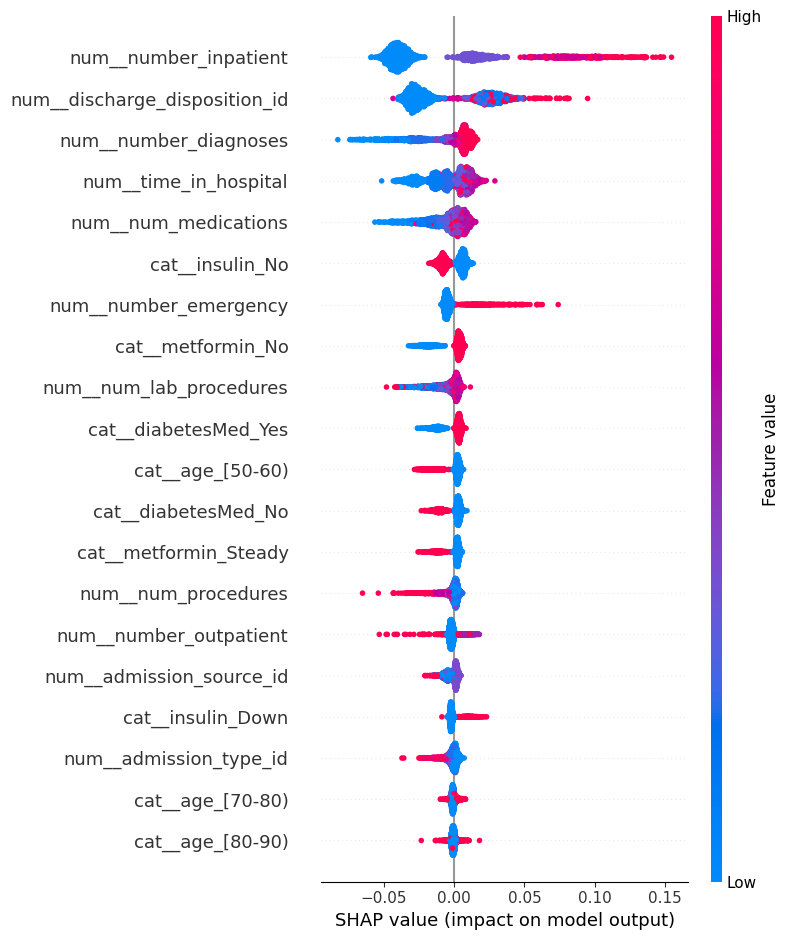

In [39]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_shap_transformed,
    feature_names=feature_names
)

In [40]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": np.abs(shap_values[:, :, 1]).mean(axis=0)
}).sort_values("Mean_SHAP", ascending=False)

shap_importance.head(15)

,Feature,Mean_SHAP
9,num__number_inpatient,0.042551
1,num__discharge_disposition_id,0.027008
10,num__number_diagnoses,0.013629
3,num__time_in_hospital,0.011415
6,num__num_medications,0.009478
78,cat__insulin_No,0.007009
8,num__number_emergency,0.006988
25,cat__metformin_No,0.006339
4,num__num_lab_procedures,0.006130
96,cat__diabetesMed_Yes,0.005467


In [41]:
shap_importance.to_csv(
    "../data/processed/shap_importance.csv",
    index=False
)

In [48]:
import matplotlib.pyplot as plt

In [51]:
plt.tight_layout()
plt.savefig(
    "../visualizations/modelling/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [42]:
results_df.sort_values("ROC_AUC", ascending=False)

,Model,Precision,Recall,F1,ROC_AUC
1,Decision Tree,0.173908,0.606341,0.270291,0.661715
2,Random Forest,0.187555,0.469837,0.268090,0.659739
0,Logistic Regression,0.172841,0.521797,0.259669,0.647412


In [43]:
shap_importance.head(10)

,Feature,Mean_SHAP
9,num__number_inpatient,0.042551
1,num__discharge_disposition_id,0.027008
10,num__number_diagnoses,0.013629
3,num__time_in_hospital,0.011415
6,num__num_medications,0.009478
78,cat__insulin_No,0.007009
8,num__number_emergency,0.006988
25,cat__metformin_No,0.006339
4,num__num_lab_procedures,0.006130
96,cat__diabetesMed_Yes,0.005467


In [44]:
results

[{'Model': 'Logistic Regression',
  'Precision': 0.17284130688448074,
  'Recall': 0.5217965653896962,
  'F1': 0.25966911361893286,
  'ROC_AUC': np.float64(0.6474116623496435)},
 {'Model': 'Decision Tree',
  'Precision': 0.1739075524122253,
  'Recall': 0.6063408190224571,
  'F1': 0.27029149082343706,
  'ROC_AUC': np.float64(0.6617151359868982)},
 {'Model': 'Random Forest',
  'Precision': 0.18755493056776235,
  'Recall': 0.4698370761778952,
  'F1': 0.2680904522613065,
  'ROC_AUC': np.float64(0.6597387437003691)}]

In [45]:
results_df.to_csv(
    "../data/processed/model_results.csv",
    index=False
)

In [46]:
shap_importance.to_csv(
    "../data/processed/shap_importance.csv",
    index=False
)

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_shap_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig("../visualizations/modeling/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()